# 00-01 Barcelona vs Real Madrid：进入进攻三区后发生了什么？

**问题：** 两队怎样进入进攻三区？一次控球首次进入后，有多大概率到达禁区、形成射门并产生 xG？这种差异是否随比分状态改变？

**分析单位：** 一次起点满足 `x < 80`、终点满足 `x >= 80` 的 Pass 或 Carry 事件。

**预期产物：** 事件级进入图、possession 级结果图和比分状态对照。图只能描述这场比赛中的记录，不能单独证明球队的稳定风格或战术原因。

## 学习路径

1. 读取一场比赛的原始 events JSON，并用仓库工具箱生成可审查的比赛证据包。
2. 把 Pass 和 Carry 的进入记录整理成统一事件表。
3. 按球队、方式、传球高度和球员汇总。
4. 在 StatsBomb 球场坐标上画出每次进入。
5. 每次 possession 只保留第一次成功进入，并检查后续禁区行动、射门和 xG。
6. 审计供应商标记的反击与四个进球事件链，区分数据事实和足球解释。
7. 按比分状态比较结果，并说明事件数据的证据边界。

In [1]:
from __future__ import annotations

import json

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D
from mplsoccer import Pitch

from football_analytics import (
    build_match_evidence,
    get_open_data_root,
    get_project_root,
)

MATCH_ID = 3773585
SOURCE_COMMIT = "b0bc9f22dd77c206ddedc1d742893b3bbe64baec"
PROJECT_ROOT = get_project_root()
OPEN_DATA_ROOT = get_open_data_root(PROJECT_ROOT)
EVENTS_PATH = OPEN_DATA_ROOT / "data" / "events" / f"{MATCH_ID}.json"

with EVENTS_PATH.open() as handle:
    events = json.load(handle)

evidence = build_match_evidence(events)
len(events), EVENTS_PATH.relative_to(PROJECT_ROOT), SOURCE_COMMIT

(4213,
 PosixPath('data/external/statsbomb-open-data/data/events/3773585.json'),
 'b0bc9f22dd77c206ddedc1d742893b3bbe64baec')

## 1. 建立进入事件表

`build_match_evidence` 是本课沉淀的可复用接口。它读取原始 event records，返回
JSON 可序列化的证据包；Notebook 只负责把证据转成表格、图形和足球叙事。

`Pass` 的终点位于 `pass.end_location`，`Carry` 的终点位于
`carry.end_location`。StatsBomb 的 `Dribble` 表示一次过人尝试，不提供这类持续
移动的终点，因此这里使用 Carry 表示持球推进。

成功传球没有 `pass.outcome` 字段。工具箱保留 `play_pattern` 和 `pass_type`，
以便之后区分常规进攻、界外球和定位球来源。

In [2]:
entries = pd.DataFrame(evidence["final_third_entries"])
entries.head(8)

,event_id,event_index,possession,minute,team,player,method,play_pattern,pass_type,pass_height,length,start_x,start_y,end_x,end_y
0,31509e6a-d5b1-4a94-a47b-c77d9492c1c4,127,3,2,Barcelona,Lionel Andrés Messi Cuccittini,Pass,Regular Play,NaN,Low Pass,32.088783,70.5,51.1,91.8,75.1
1,84b89d6a-8952-4d07-93e0-881f462e0ec1,183,7,3,Barcelona,Lionel Andrés Messi Cuccittini,Carry,Regular Play,NaN,NaN,4.716991,76.5,40.9,80.5,38.4
2,07c22583-e3ac-473d-ba43-89e923e4b55b,242,10,3,Real Madrid,Carlos Henrique Casimiro,Pass,From Keeper,NaN,High Pass,48.325665,44.1,45.9,83.2,17.5
3,74e2e017-da8e-4c91-ba74-e1e58e4fa39a,285,10,4,Real Madrid,Karim Benzema,Carry,From Keeper,NaN,NaN,16.348700,69.0,67.8,84.8,63.6
4,ee6e8929-5336-40cb-8321-b59a3eaab9b8,331,12,6,Real Madrid,Karim Benzema,Carry,Regular Play,NaN,NaN,20.412006,72.7,14.7,93.1,15.4
5,a26559f0-d5f9-474c-be25-c2ad857a6776,352,12,6,Real Madrid,Raphaël Varane,Pass,Regular Play,NaN,High Pass,53.976753,57.8,47.1,94.8,7.8
6,cb049c3e-6595-47fd-9b72-c86fc32b9361,385,14,7,Barcelona,Lionel Andrés Messi Cuccittini,Pass,From Free Kick,NaN,High Pass,46.536976,68.6,9.3,112.3,25.3
7,a667bd52-cbc8-4ca4-96d5-306adb14339d,426,17,9,Barcelona,Sergio Busquets i Burgos,Pass,Regular Play,NaN,Ground Pass,15.061541,69.3,29.8,83.2,35.6


In [3]:
assert len(entries) == 117
assert set(entries["method"]) == {"Pass", "Carry"}
assert entries["event_id"].is_unique
assert entries["start_x"].lt(80).all()
assert entries["end_x"].ge(80).all()

pd.Series(
    {
        "source_events": len(events),
        "final_third_entries": len(entries),
        "teams": entries["team"].nunique(),
        "players": entries["player"].nunique(),
    },
    name="data fact",
).to_frame()

,data fact
source_events,4213
final_third_entries,117
teams,2
players,24


上面的断言检查了本课定义，而不是验证比赛表现：每行必须是唯一事件、起点在三区外、终点在三区内。

In [4]:
method_counts = pd.crosstab(entries["team"], entries["method"]).reindex(
    columns=["Pass", "Carry"], fill_value=0
)
method_counts["Total"] = method_counts.sum(axis=1)

pass_entries = entries.loc[entries["method"] == "Pass"].copy()
height_order = ["Ground Pass", "Low Pass", "High Pass"]
height_counts = pd.crosstab(pass_entries["team"], pass_entries["pass_height"]).reindex(
    columns=height_order, fill_value=0
)
pass_length_summary = (
    pass_entries.groupby("team")["length"]
    .agg(count="size", median="median", mean="mean")
    .round(2)
)

method_counts, height_counts, pass_length_summary

(method       Pass  Carry  Total
 team                           
 Barcelona      40     23     63
 Real Madrid    34     20     54,
 pass_height  Ground Pass  Low Pass  High Pass
 team                                         
 Barcelona             33         5          2
 Real Madrid           22         2         10,
              count  median   mean
 team                             
 Barcelona       40   19.28  22.38
 Real Madrid     34   21.00  26.38)

## 2. 球队层面的方式与高度

左图比较进入次数和方式；右图只看成功传球，并拆分 Ground、Low、High。原始数量会受到控球和比赛状态影响，因此这里先描述，不直接称为球队风格。

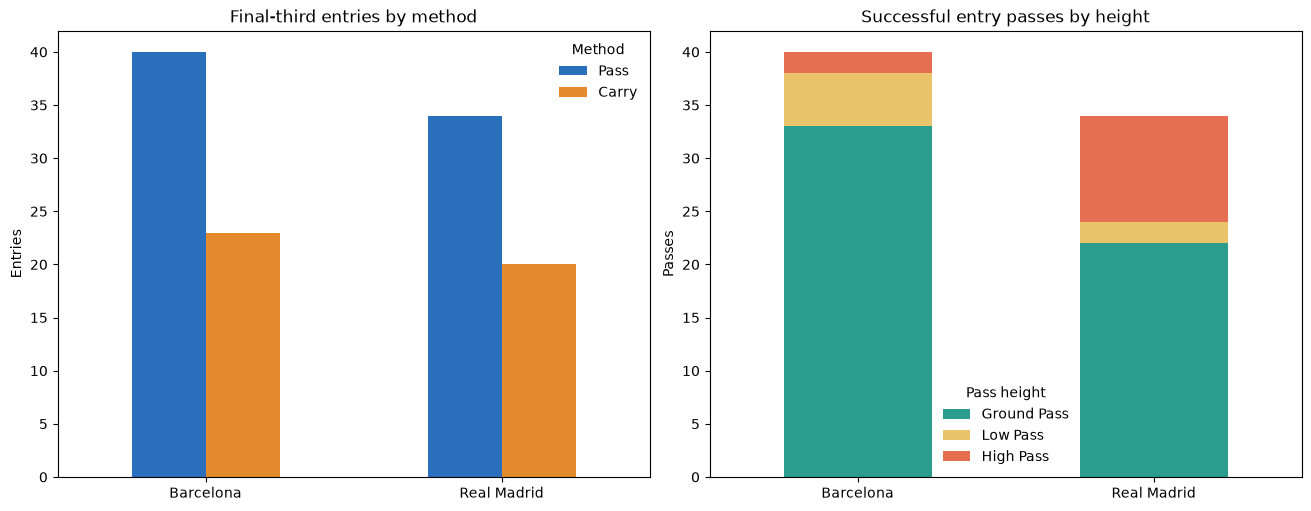

In [5]:
team_order = ["Barcelona", "Real Madrid"]
method_colors = {"Pass": "#2A6FBB", "Carry": "#E38B2C"}
height_colors = {
    "Ground Pass": "#2A9D8F",
    "Low Pass": "#E9C46A",
    "High Pass": "#E76F51",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
method_counts.loc[team_order, ["Pass", "Carry"]].plot.bar(
    ax=axes[0], color=[method_colors["Pass"], method_colors["Carry"]], rot=0
)
axes[0].set(title="Final-third entries by method", xlabel="", ylabel="Entries")
axes[0].legend(title="Method", frameon=False)

height_counts.loc[team_order, height_order].plot.bar(
    ax=axes[1],
    stacked=True,
    color=[height_colors[name] for name in height_order],
    rot=0,
)
axes[1].set(title="Successful entry passes by height", xlabel="", ylabel="Passes")
axes[1].legend(title="Pass height", frameon=False)
plt.show()

## 3. 哪些球员完成进入？

每队选取进入次数最多的五名球员，并在同一条形中拆分 Pass 和 Carry。这里衡量的是这场比赛中的事件贡献，不等同于球员能力。

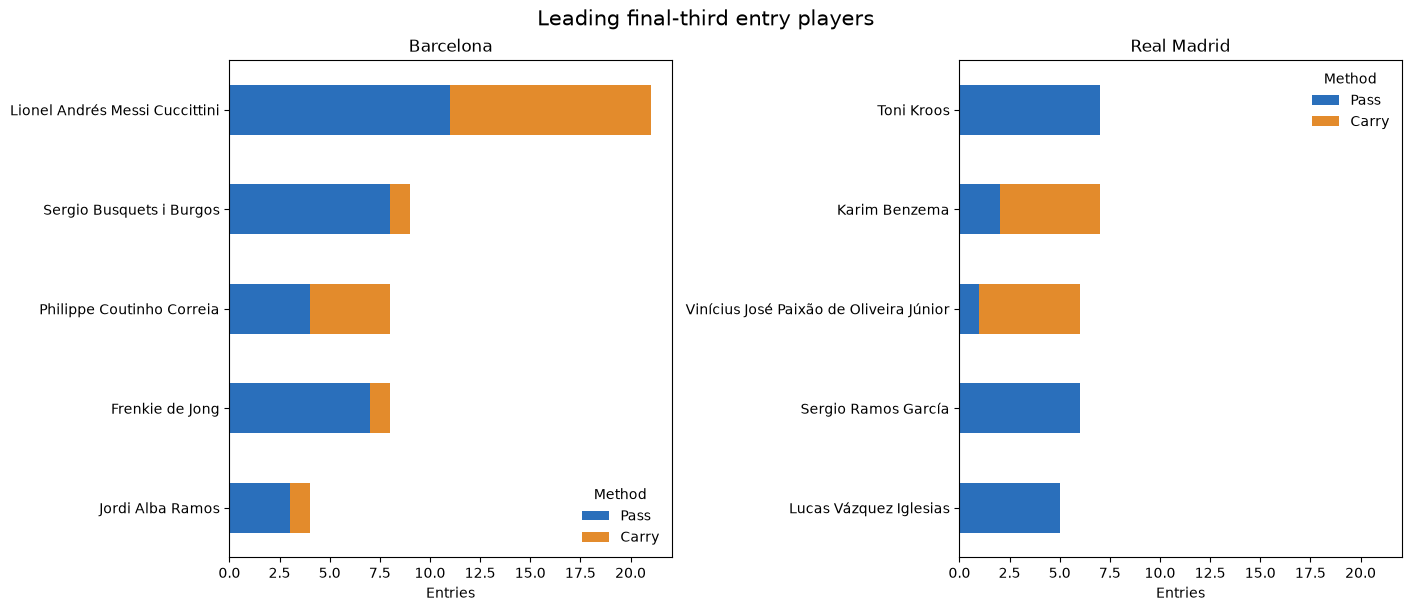

In [6]:
player_method = (
    entries.groupby(["team", "player", "method"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Pass", "Carry"], fill_value=0)
)
player_method["Total"] = player_method.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True, sharex=True)
for ax, team in zip(axes, team_order, strict=True):
    top = player_method.loc[team].nlargest(5, "Total").sort_values("Total")
    top[["Pass", "Carry"]].plot.barh(
        ax=ax, stacked=True, color=[method_colors["Pass"], method_colors["Carry"]]
    )
    ax.set(title=team, xlabel="Entries", ylabel="")
    ax.legend(title="Method", frameon=False)
fig.suptitle("Leading final-third entry players", fontsize=15)
plt.show()

## 4. 进入发生在哪里？

箭头起点在 `x < 80`，终点在阴影表示的进攻三区。颜色表示 Pass 或 Carry。大量重叠本身也是信息：下一步可以按路线、比赛时间或进攻来源继续拆分，而不是只美化图形。

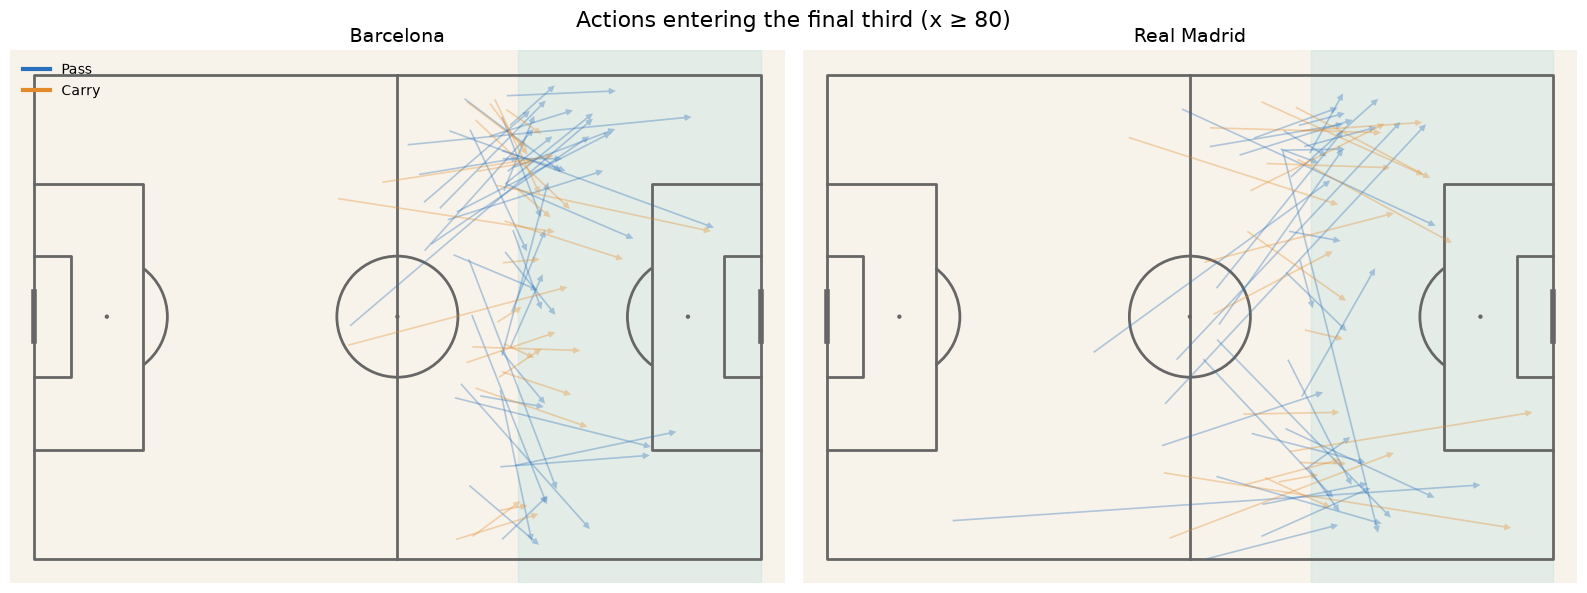

In [7]:
pitch = Pitch(pitch_type="statsbomb", pitch_color="#F7F3EA", line_color="#666666")
fig, axes = pitch.draw(ncols=2, figsize=(16, 6), constrained_layout=True)

for ax, team in zip(axes, team_order, strict=True):
    ax.axvspan(80, 120, color="#A8DADC", alpha=0.25, zorder=0)
    for method in ["Pass", "Carry"]:
        subset = entries.loc[(entries["team"] == team) & (entries["method"] == method)]
        pitch.arrows(
            subset["start_x"],
            subset["start_y"],
            subset["end_x"],
            subset["end_y"],
            ax=ax,
            color=method_colors[method],
            alpha=0.35,
            width=1.2,
            headwidth=4,
            headlength=4,
        )
    ax.set_title(team, fontsize=14)

legend = [
    Line2D([0], [0], color=method_colors["Pass"], lw=3, label="Pass"),
    Line2D([0], [0], color=method_colors["Carry"], lw=3, label="Carry"),
]
axes[0].legend(handles=legend, loc="upper left", frameon=False)
fig.suptitle("Actions entering the final third (x ≥ 80)", fontsize=16)
plt.show()

## 5. 从进入事件转向 possession 结果

同一次控球可能多次退出并重新进入进攻三区，因此117个事件不是117个独立进攻机会。这里按 StatsBomb `possession` 分组，每次控球只保留第一次成功进入。

后续结果分成两个并列问题：球队是否在同一次控球中记录到禁区内行动，以及是否形成射门。二者不是严格漏斗，因为球队可能从禁区外直接射门。xG 和进球只统计首次进入之后、同一次控球内的射门。

In [8]:
possession_outcomes = pd.DataFrame(evidence["entry_possessions"])
assert len(possession_outcomes) == 78
assert possession_outcomes["possession"].is_unique
assert possession_outcomes.groupby("team").size().to_dict() == {
    "Barcelona": 44,
    "Real Madrid": 34,
}
assert possession_outcomes["reached_box"].sum() == 41
assert possession_outcomes["has_shot"].sum() == 17
possession_outcomes.head()

,possession,team,entry_minute,entry_player,entry_method,entry_height,play_pattern,score_state,reached_box,has_shot,xg,goal
0,3,Barcelona,2,Lionel Andrés Messi Cuccittini,Pass,Low Pass,Regular Play,Level,False,False,0.000000,False
1,7,Barcelona,3,Lionel Andrés Messi Cuccittini,Carry,NaN,Regular Play,Level,True,False,0.000000,False
2,10,Real Madrid,3,Carlos Henrique Casimiro,Pass,High Pass,From Keeper,Level,True,True,0.312147,True
3,12,Real Madrid,6,Karim Benzema,Carry,NaN,Regular Play,Leading,True,True,0.142474,False
4,14,Barcelona,7,Lionel Andrés Messi Cuccittini,Pass,High Pass,From Free Kick,Trailing,True,True,0.395557,True


### 进球审计

在计算转化前先检查四个进球是否都能被定义捕获。点球 possession 可以直接从一次 Shot 开始，不一定有此前的成功 Pass 或 Carry 穿过 `x=80`；这种进球应被明确排除，而不是为了让漏斗覆盖最终比分而修改定义。

In [9]:
captured_possessions = set(possession_outcomes["possession"])
goal_audit = pd.DataFrame(
    {
        "minute": goal["minute"],
        "team": goal["team"],
        "player": goal["player"],
        "shot_type": goal["shot_type"],
        "possession": goal["possession"],
        "captured_after_entry": goal["possession"] in captured_possessions,
    }
    for goal in evidence["goals"]
)
assert len(goal_audit) == 4
assert goal_audit["captured_after_entry"].sum() == 3
goal_audit

,minute,team,player,shot_type,possession,captured_after_entry
0,4,Real Madrid,Federico Santiago Valverde Dipetta,Open Play,10,True
1,7,Barcelona,Anssumane Fati,Open Play,14,True
2,62,Real Madrid,Sergio Ramos García,Penalty,114,False
3,89,Real Madrid,Luka Modrić,Open Play,167,True


## 6. 两队进入后的结果

原始次数回答“发生了多少次”，转化率回答“进入以后发生了什么”。`xG per entry possession` 把后续射门质量分摊到所有进入三区的控球，比单场进球率更稳定，但仍只是一个比赛样本。

In [10]:
outcome_summary = possession_outcomes.groupby("team").agg(
    entry_possessions=("possession", "size"),
    reached_box=("reached_box", "sum"),
    shot_possessions=("has_shot", "sum"),
    xg=("xg", "sum"),
    goals=("goal", "sum"),
)
outcome_summary["box_reach_rate"] = (
    outcome_summary["reached_box"] / outcome_summary["entry_possessions"]
)
outcome_summary["shot_rate"] = (
    outcome_summary["shot_possessions"] / outcome_summary["entry_possessions"]
)
outcome_summary["xg_per_entry_possession"] = (
    outcome_summary["xg"] / outcome_summary["entry_possessions"]
)
outcome_summary.round(3)

,entry_possessions,reached_box,shot_possessions,xg,goals,box_reach_rate,shot_rate,xg_per_entry_possession
team,,,,,,,,
Barcelona,44,25,8,1.101,1,0.568,0.182,0.025
Real Madrid,34,16,9,1.500,2,0.471,0.265,0.044


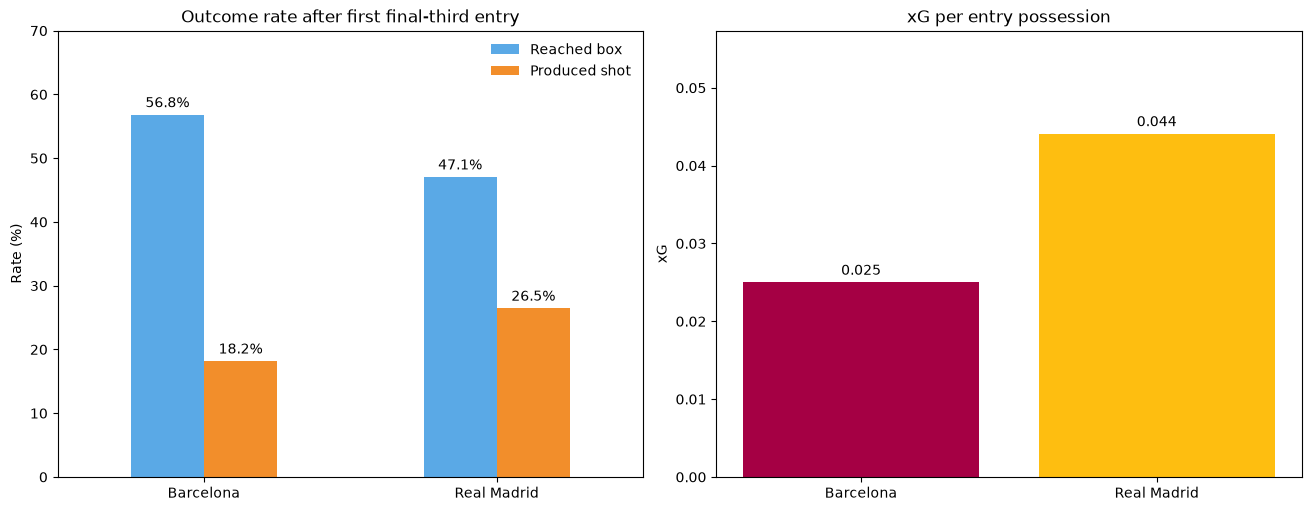

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

rate_chart = outcome_summary.loc[team_order, ["box_reach_rate", "shot_rate"]] * 100
rate_chart.columns = ["Reached box", "Produced shot"]
rate_chart.plot.bar(ax=axes[0], color=["#5AA9E6", "#F28E2B"], rot=0)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.1f%%", padding=3)
axes[0].set(
    title="Outcome rate after first final-third entry", xlabel="", ylabel="Rate (%)"
)
axes[0].set_ylim(0, 70)
axes[0].legend(frameon=False)

xg_values = outcome_summary.loc[team_order, "xg_per_entry_possession"]
bars = axes[1].bar(team_order, xg_values, color=["#A50044", "#FEBE10"])
axes[1].bar_label(bars, fmt="%.3f", padding=3)
axes[1].set(title="xG per entry possession", xlabel="", ylabel="xG")
axes[1].set_ylim(0, xg_values.max() * 1.3)
plt.show()

## 7. 比分状态是否改变结果？

比分状态按第一次进入发生前的比分、相对于执行球队定义。Barcelona 在本场没有领先状态，Real Madrid 没有落后状态。分组后的样本很小，因此图用于解释比赛过程，不用于估计稳定转化能力。

In [12]:
state_summary = possession_outcomes.groupby(["team", "score_state"]).agg(
    entry_possessions=("possession", "size"),
    reached_box=("reached_box", "sum"),
    shot_possessions=("has_shot", "sum"),
    xg=("xg", "sum"),
)
state_summary["shot_rate"] = (
    state_summary["shot_possessions"] / state_summary["entry_possessions"]
)
state_summary["xg_per_entry_possession"] = (
    state_summary["xg"] / state_summary["entry_possessions"]
)

state_order = [
    ("Barcelona", "Level"),
    ("Barcelona", "Trailing"),
    ("Real Madrid", "Level"),
    ("Real Madrid", "Leading"),
]
state_plot = state_summary.loc[state_order].reset_index()
state_plot.round(3)

,team,score_state,entry_possessions,reached_box,shot_possessions,xg,shot_rate,xg_per_entry_possession
0,Barcelona,Level,26,16,6,0.659,0.231,0.025
1,Barcelona,Trailing,18,9,2,0.441,0.111,0.025
2,Real Madrid,Level,22,10,5,0.694,0.227,0.032
3,Real Madrid,Leading,12,6,4,0.806,0.333,0.067


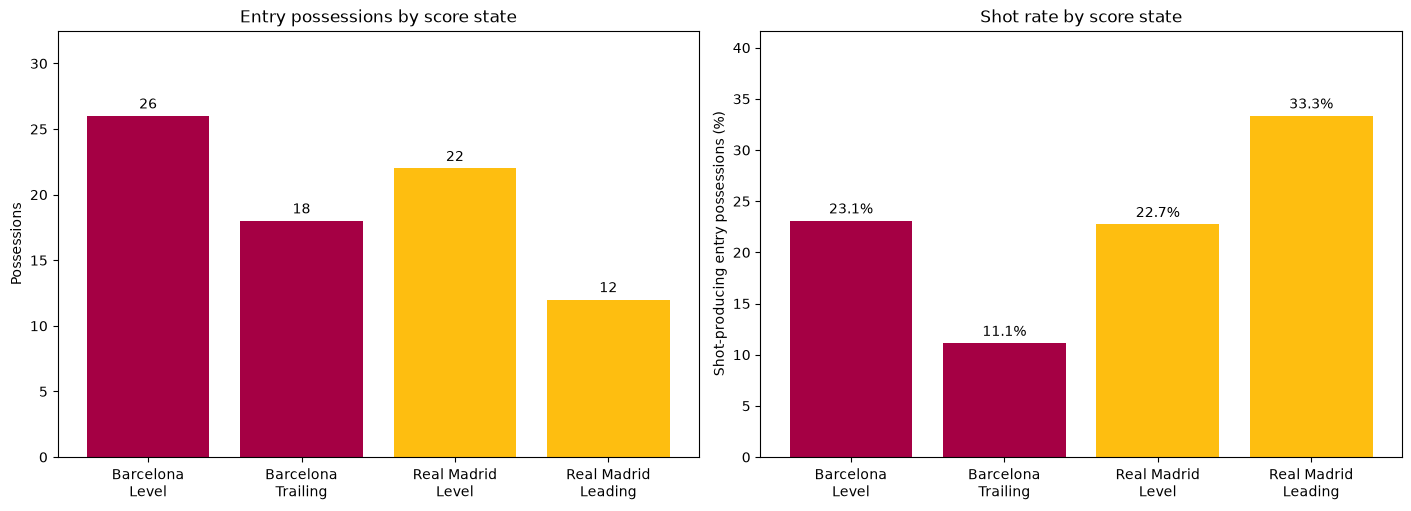

In [13]:
state_labels = [f"{team}\n{state}" for team, state in state_order]
state_colors = ["#A50044", "#A50044", "#FEBE10", "#FEBE10"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

count_bars = axes[0].bar(
    state_labels, state_plot["entry_possessions"], color=state_colors
)
axes[0].bar_label(count_bars, padding=3)
axes[0].set(title="Entry possessions by score state", ylabel="Possessions")
axes[0].set_ylim(0, state_plot["entry_possessions"].max() * 1.25)

shot_rates = state_plot["shot_rate"] * 100
rate_bars = axes[1].bar(state_labels, shot_rates, color=state_colors)
axes[1].bar_label(rate_bars, fmt="%.1f%%", padding=3)
axes[1].set(
    title="Shot rate by score state", ylabel="Shot-producing entry possessions (%)"
)
axes[1].set_ylim(0, max(40, shot_rates.max() * 1.25))
plt.show()

## 8. 四个进球分别怎样形成？

这一节只建立事实分类，不寻找一个能够解释全部进球的共同模型。每球区分：

1. StatsBomb `play_pattern` 记录的 possession 来源；
2. 最后直接形成射门的事件链；
3. event data 没有记录、不能直接判断的机制。

图中只画经过审计的关键事件，不把选中的最后事件链冒充完整战术过程。

In [14]:
events_by_index = {event["index"]: event for event in events}
goal_records = evidence["goals"]
assert [goal["event_index"] for goal in goal_records] == [289, 391, 2852, 3992]

goal_descriptions = {
    289: {
        "goal": "Valverde 5'",
        "source": "From Keeper",
        "observed_chain": (
            "60-second possession; Benzema through ball; one-on-one finish"
        ),
        "finish": "Right foot, one-on-one",
        "boundary": "Events do not identify the off-ball trigger for Valverde's run",
    },
    391: {
        "goal": "Fati 8'",
        "source": "From Free Kick",
        "observed_chain": (
            "Messi through ball to Alba; low pass; first-time half-volley"
        ),
        "finish": "Right foot, first time",
        "boundary": "Events do not show why the passing lane opened",
    },
    2852: {
        "goal": "Ramos 63'",
        "source": "Free kick -> penalty",
        "observed_chain": "Kroos high free kick; Lenglet foul on Ramos; penalty",
        "finish": "Penalty, right foot",
        "boundary": "Foul contact and correctness of the decision require video",
    },
    3992: {
        "goal": "Modrić 90'",
        "source": "From Goal Kick",
        "observed_chain": "Incomplete goal kick; Rodrygo high recovery; pass; dribble",
        "finish": "Right foot after complete dribble",
        "boundary": "Events do not continuously show Barcelona's recovery shape",
    },
}

goal_fact_rows = []
for goal in goal_records:
    description = goal_descriptions[goal["event_index"]]
    goal_fact_rows.append(
        {
            "goal": description["goal"],
            "team": goal["team"],
            "source": description["source"],
            "provider_pattern": goal["play_pattern"],
            "observed_chain": description["observed_chain"],
            "direct_assist": (
                goal["key_pass"]["player"] if goal["key_pass"] else "None"
            ),
            "shot_xg": goal["shot_xg"],
            "finish": description["finish"],
            "evidence_boundary": description["boundary"],
        }
    )

goal_facts = pd.DataFrame(goal_fact_rows)

# The penalty award is linked from the Foul Won event even though the shot starts
# a new possession.
penalty_goal = next(goal for goal in goal_records if goal["shot_type"] == "Penalty")
penalty_award = penalty_goal["penalty_award"]
assert penalty_award is not None
assert penalty_award["foul_committed"]["player"] == "Clément Lenglet"
assert penalty_award["foul_won"]["player"] == "Sergio Ramos García"

kroos_free_kick = events_by_index[2848]
assert kroos_free_kick["pass"]["type"]["name"] == "Free Kick"
assert kroos_free_kick["pass"]["height"]["name"] == "High Pass"

goal_facts[["goal", "source", "provider_pattern", "observed_chain", "shot_xg"]].round(3)

,goal,source,observed_chain,shot_xg
0,Valverde 5',From Keeper,60-second possession; Benzema through ball; on...,0.312
1,Fati 8',From Free Kick,Messi through ball to Alba; low pass; first-ti...,0.396
2,Ramos 63',Free kick -> penalty,Kroos high free kick; Lenglet foul on Ramos; p...,0.784
3,Modrić 90',From Goal Kick,Incomplete goal kick; Rodrygo high recovery; p...,0.294


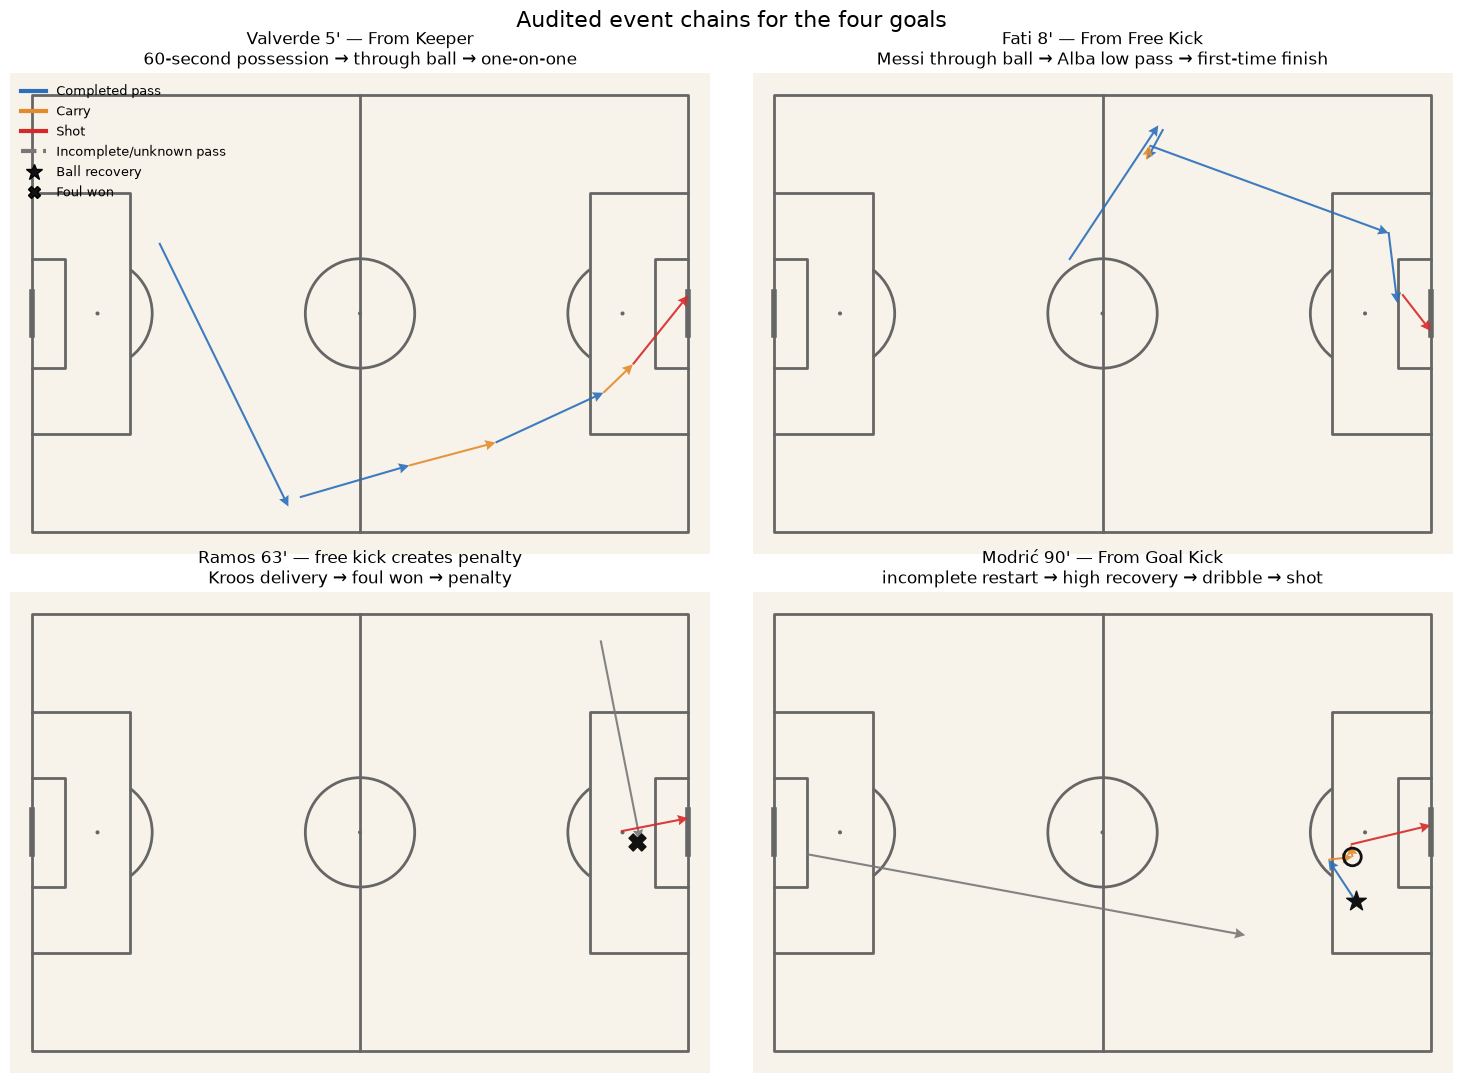

In [15]:
goal_chains = {
    "Valverde 5' — From Keeper\n60-second possession → through ball → one-on-one": [
        280,
        283,
        285,
        286,
        288,
        289,
    ],
    (
        "Fati 8' — From Free Kick\n"
        "Messi through ball → Alba low pass → first-time finish"
    ): [
        379,
        382,
        384,
        385,
        387,
        388,
        391,
    ],
    "Ramos 63' — free kick creates penalty\nKroos delivery → foul won → penalty": [
        2848,
        2850,
        2852,
    ],
    (
        "Modrić 90' — From Goal Kick\n"
        "incomplete restart → high recovery → dribble → shot"
    ): [
        3969,
        3984,
        3986,
        3988,
        3990,
        3991,
        3992,
    ],
}

action_colors = {
    "Pass": "#2A6FBB",
    "Carry": "#E38B2C",
    "Shot": "#D62828",
}
pitch = Pitch(
    pitch_type="statsbomb",
    pitch_color="#F7F3EA",
    line_color="#666666",
)
fig, axes = pitch.draw(nrows=2, ncols=2, figsize=(15, 11), constrained_layout=True)

for ax, (title, event_indices) in zip(axes.flat, goal_chains.items(), strict=True):
    for event_index in event_indices:
        event = events_by_index[event_index]
        event_type = event["type"]["name"]
        location = event.get("location")
        if event_type in {"Pass", "Carry", "Shot"}:
            detail = event[event_type.lower()]
            end_location = detail.get("end_location")
            if location and end_location:
                incomplete = event_type == "Pass" and detail.get("outcome", {}).get(
                    "name"
                ) not in {None, "Complete"}
                pitch.arrows(
                    location[0],
                    location[1],
                    end_location[0],
                    end_location[1],
                    ax=ax,
                    color="#777777" if incomplete else action_colors[event_type],
                    alpha=0.9,
                    width=1.5,
                    headwidth=5,
                    headlength=5,
                    linestyle="--" if incomplete else "-",
                )
        elif event_type == "Ball Recovery":
            pitch.scatter(
                location[0],
                location[1],
                ax=ax,
                marker="*",
                color="#111111",
                s=220,
                zorder=5,
            )
        elif event_type == "Foul Won":
            pitch.scatter(
                location[0],
                location[1],
                ax=ax,
                marker="X",
                color="#111111",
                s=150,
                zorder=5,
            )
        elif event_type == "Dribble":
            pitch.scatter(
                location[0],
                location[1],
                ax=ax,
                facecolor="none",
                edgecolor="#111111",
                linewidth=2,
                s=160,
                zorder=5,
            )
    ax.set_title(title, fontsize=12)

legend = [
    Line2D([0], [0], color=action_colors["Pass"], lw=3, label="Completed pass"),
    Line2D([0], [0], color=action_colors["Carry"], lw=3, label="Carry"),
    Line2D([0], [0], color=action_colors["Shot"], lw=3, label="Shot"),
    Line2D(
        [0], [0], color="#777777", lw=3, linestyle="--", label="Incomplete/unknown pass"
    ),
    Line2D(
        [0],
        [0],
        marker="*",
        color="none",
        markerfacecolor="#111111",
        markersize=12,
        label="Ball recovery",
    ),
    Line2D(
        [0],
        [0],
        marker="X",
        color="none",
        markerfacecolor="#111111",
        markersize=9,
        label="Foul won",
    ),
]
axes.flat[0].legend(handles=legend, loc="upper left", frameon=False, fontsize=9)
fig.suptitle("Audited event chains for the four goals", fontsize=16)
plt.show()

### 四球事实分类

- **Valverde：持续控球后的直塞单刀。** `From Keeper` possession 持续约60秒，中途明显回收和横向转移；最后由 Nacho 找到 Benzema，Benzema 带球后送出标记为 `Through Ball` 的助攻，Valverde 单刀射门。它不是一次从门将直接发动到射门的连续快攻。
- **Fati：定位球来源、开放比赛式完成。** possession 从后场任意球开始，但进球不是直接任意球：Messi 直塞 Alba，Alba 低平球传中路，Fati 第一时间半凌空完成。
- **Ramos：任意球制造的点球。** Kroos 高球任意球传入禁区，1.25秒后数据成对记录 Lenglet `Foul Committed` 和 Ramos `Foul Won`，两者均标记 `penalty=True`。event data 没有记录具体接触方式，不能判断判罚是否合理。
- **Modrić：球门球来源中的破碎回合。** Courtois 长球未成功；此后双方都有球上动作。最后 Rodrygo 在 `x=106.3` 回收球权并助攻，Modrić 完成过人后射门。`From Goal Kick` 描述 possession 来源，不表示球门球直接制造了进球。

四球没有共同的单一来源：一个是持续控球后的直塞、一个是任意球延续后的组合、一个是任意球制造点球、一个是破碎回合中的高位回收。这是数据事实与基于事件链的分类；为何空间出现、跑位如何制造机会，仍属于需要360或视频验证的解释。

## 当前读法与证据边界

- **数据事实：** 原始文件包含 4,213 个 events；本课定义筛出 117 次进入。四个进球分别属于持续控球后的直塞单刀、任意球延续后的开放式组合、任意球制造点球，以及球门球来源破碎回合中的高位回收。
- **指标结果：** 117次事件属于78个至少成功进入一次三区的 possession。Barcelona 有44个，25个后续到达禁区、8个形成射门、产生1.101 xG；Real Madrid 有34个，16个到达禁区、9个形成射门、产生1.500 xG。
- **供应商标签：** `From Keeper`、`From Free Kick` 和 `From Goal Kick` 描述 possession 的来源，不能替代对最后得分机制的事件链审计。StatsBomb 本场的两个 `From Counter` 均不对应进球。
- **足球解释：** Real Madrid 的比分优势不是由一种重复得分模式构成；其三球分别依靠直塞单刀、定位球制造点球和高位回收后的个人处理。
- **证据边界：** event data 可以重建球上动作、助攻、犯规标签和射门结果，不能连续观察跑位、接触过程、整体防守结构或裁判判断。

当前结果仍包含不同 `play_pattern`。直接界外球是 `pass_type=Throw-in`，而界外球发起的后续进攻是 `play_pattern=From Throw In`；二者不能混为一谈。禁区到达定义为同队后续事件的起点，或成功 Pass/Carry 的终点位于禁区内；它不是精确识别一次穿过禁区边界的动作。

## 可复用工具箱

同样的证据抽取不必在下一场比赛里重写。Python 代码可以调用
`build_match_evidence(events)`；Agent 或学习者也可以直接运行：

```bash
uv run match-evidence --match-id 3773585 --format markdown
```

输出包含进入事件、首次进入 possession 的后续结果、StatsBomb 标记的
`From Counter` possessions，以及可回溯到助攻和点球犯规的进球证据。它提供的是
稳定、可审查的事实接口，不自动把事件链解释为战术原因。

## 练习

1. 不看上面的文字，只根据四球事件图写出每球的“来源标签”和“最后得分机制”；比较两者为何不同。
2. 检查 Ramos 点球前成对关联的 `Foul Committed` 与 `Foul Won`。哪些是数据事实，哪些仍需要视频？
3. 为每个进球写一个可能的足球解释和一个替代解释，并指出需要什么额外证据才能区分。

In [16]:
regular_play_entries = entries.loc[entries["play_pattern"] == "Regular Play"]
pd.crosstab(regular_play_entries["team"], regular_play_entries["method"]).reindex(
    columns=["Pass", "Carry"], fill_value=0
)

method,Pass,Carry
team,,
Barcelona,19,13
Real Madrid,18,13
